In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
import scipy.signal as sig

import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

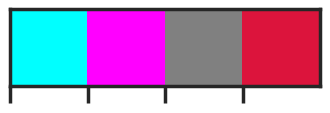

In [3]:
pal=sns.blend_palette(['cyan','magenta','gray','crimson'],4)
sns.palplot(pal)
sns.set_palette(pal)

In [4]:
plt.rcdefaults()

# Load some necessary variables

In [5]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1100)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1100-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1100-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 200.0 80.0 140.0


In [6]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

In [7]:
base_idx = [0, 400]
min_freq = 2
max_freq = 90 #40,50
num_frex = 40
range_cycles = [3, 10]

# data info
Sampling_Rate = 2500.
num_samples = 7350

#frequencies vector
frex = np.logspace(np.log10(min_freq),np.log10(max_freq),num_frex)
time = np.linspace(0, num_samples, int(num_samples) )

In [8]:
# Trials grouped into average across 5
def butter_bandpass_filter(data, lowcutoff=4, highcutoff=8, fs=2500, order=6):
    nyq = 0.5 * fs  # Nyquist Frequency
    high_cutoff = highcutoff / nyq
    low_cutoff = lowcutoff / nyq
    # Get the filter coefficients 
    b, a = sig.butter(order, high_cutoff, btype='low', analog=False)
    y = sig.filtfilt(b, a, data)
    b2, a2 = sig.butter(order, low_cutoff, btype='high', analog=False)
    y2 = sig.filtfilt(b2, a2, y)
    return y2

# load in the trial averaged arrays

In [9]:
scenario = input('what situation (rew, rew2, unrew, novel): ') #rew, rew2, unrew, novel

if scenario == "rew":
    wt_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wt_allmouse_mean_rew.npy")
    fx_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\fx_allmouse_mean_rew.npy")
elif scenario == "rew2":
    wt_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wt_allmouse_mean_rew2.npy")
    fx_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\fx_allmouse_mean_rew2.npy")
elif scenario == "unrew":
    wt_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wt_allmouse_mean_unrew.npy")
    fx_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\fx_allmouse_mean_unrew.npy")
elif scenario == "novel":
    wt_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wt_allmouse_mean_novel.npy")
    fx_allmouse_mean = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\fx_allmouse_mean_novel.npy")

what situation (rew, rew2, unrew, novel):  rew


# Load in plv/phd dataFrames

In [10]:
rew_plv = pd.read_pickle(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wtfx_plv_rew.pkl")
rew2_plv = pd.read_pickle(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wtfx_plv_rew2.pkl")
unrew_plv = pd.read_pickle(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wtfx_plv_unrew.pkl")
novel_plv = pd.read_pickle(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd\wtfx_plv_novel.pkl")

big_plv = pd.concat([rew_plv, rew2_plv, unrew_plv, novel_plv], ignore_index=True)

In [11]:
wtfx_plv_df = big_plv[big_plv.situ == scenario]

wt_tmpdf = wtfx_plv_df[wtfx_plv_df.group == 'wt']
fx_tmpdf = wtfx_plv_df[wtfx_plv_df.group == 'fx']

# Plotting

In [12]:

yes_save_plots = False #True, False ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

wt_v1ch, fx_v1ch = 260, 260
wt_hpcch, fx_hpcch = 160, 160

In [13]:
wttest_cha = wt_allmouse_mean[:,wt_v1ch,:]
wtstandard_dev = np.std(wttest_cha, axis=0)
wttest_mean_mean = wttest_cha.mean(axis=0)
sr=2500
wttest_time_cha = np.linspace(0, wttest_cha.shape[1]/sr, wttest_cha.shape[1])

In [14]:
fxtest_cha = fx_allmouse_mean[:,fx_v1ch,:]
fxstandard_dev = np.std(fxtest_cha, axis=0)
fxtest_mean_mean = fxtest_cha.mean(axis=0)
sr=2500
fxtest_time_cha = np.linspace(0, fxtest_cha.shape[1]/sr, fxtest_cha.shape[1])

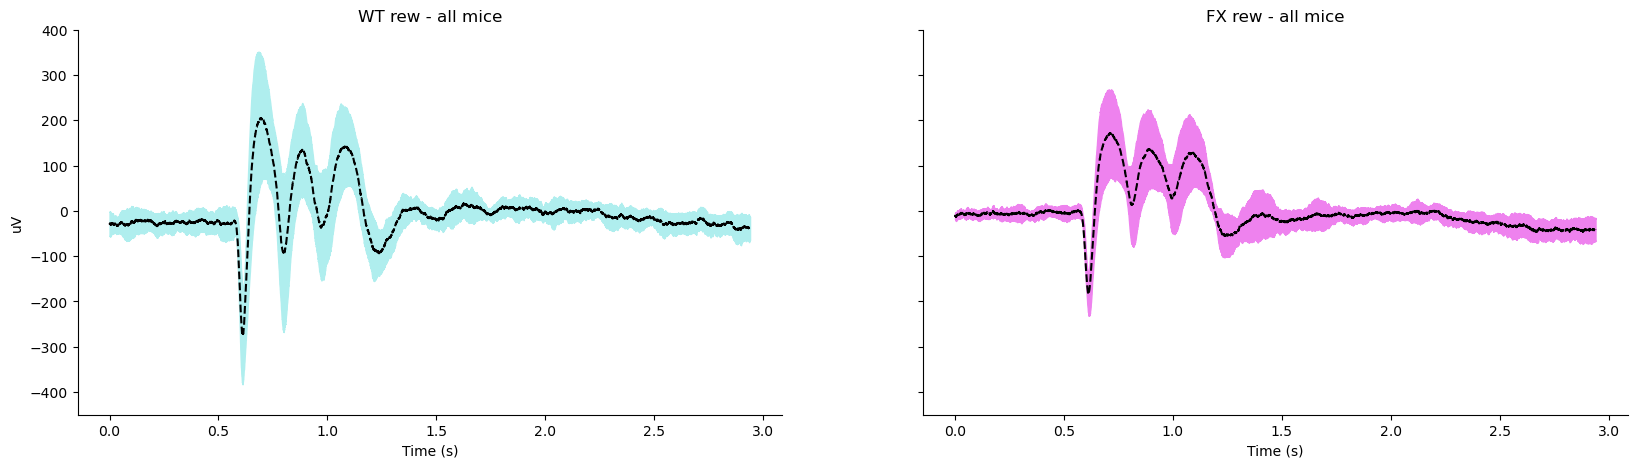

In [15]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,5), sharex=True, sharey=True)

ax[0].plot(wttest_time_cha, wttest_mean_mean, color='black', linestyle='dashed')
ax[0].fill_between(wttest_time_cha, wttest_mean_mean-wtstandard_dev, wttest_mean_mean+wtstandard_dev, color='paleturquoise')
ax[0].set_title(f'WT {scenario} - all mice')

ax[1].plot(fxtest_time_cha, fxtest_mean_mean, color='black', linestyle='dashed')
ax[1].fill_between(fxtest_time_cha, fxtest_mean_mean-fxstandard_dev, fxtest_mean_mean+fxstandard_dev, color='violet')
ax[1].set_title(f'FX {scenario} - all mice')

ax[0].set_ylabel('uV')
ax[0].set_ylim([-450,400])
ax[0].set_xlabel('Time (s)')
ax[1].set_xlabel('Time (s)')

sns.despine()

# if yes_save_plots:
#     file_name = f"LFP_wtfx_{scenario}.pdf"
#     out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
#     plt.savefig(out_path, transparent=True)
    
plt.show()

# WT --- V1:HPC Veps, Theta filtered Veps, and PLV

In [16]:
my_all_mean = wt_allmouse_mean.mean(axis=0) #mean across trials for each mouse then across mice

# can manually choose a channel if you want to
V1_mean_ch = wt_v1ch
HPC_mean_ch = wt_hpcch

print(f'V1 channel: {V1_mean_ch} --- HPC channel: {HPC_mean_ch}')
sr=2500

V1 channel: 260 --- HPC channel: 160


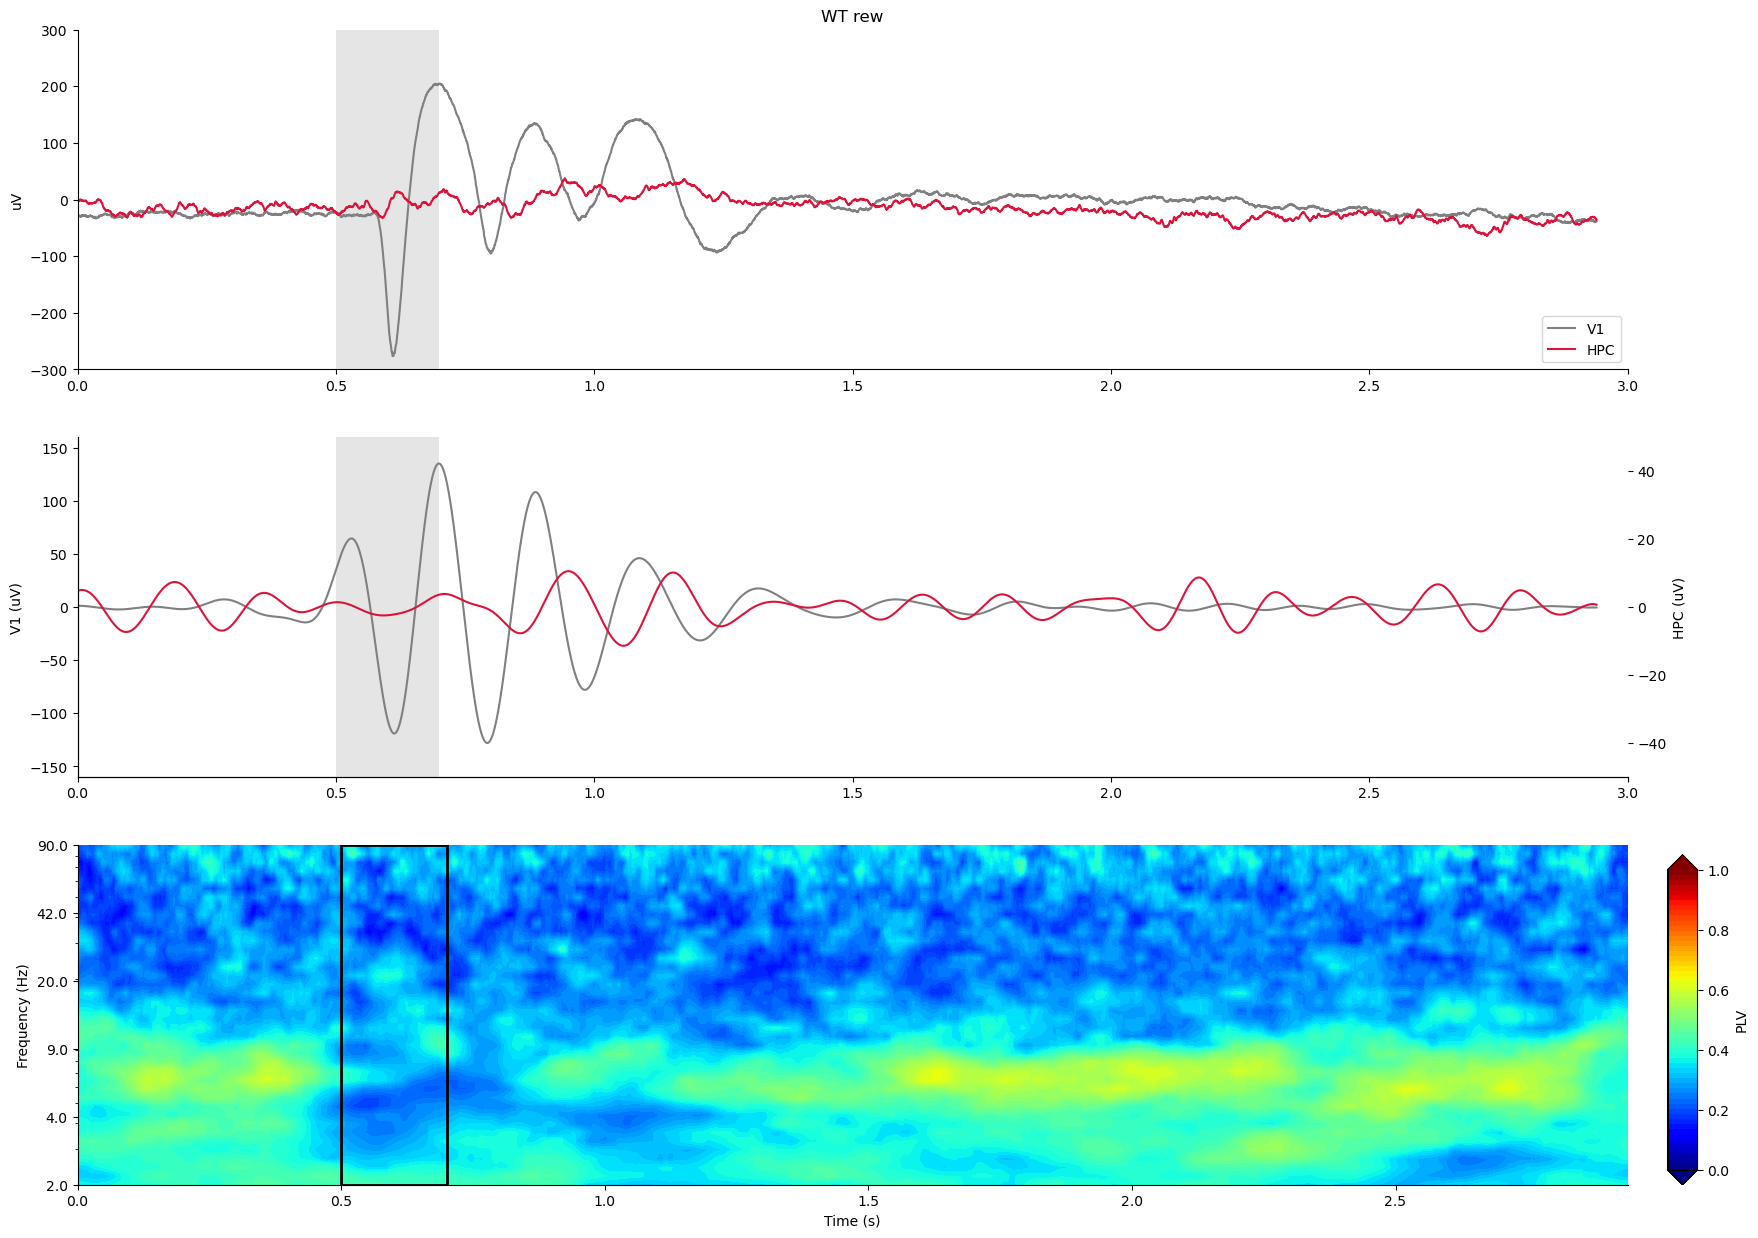

In [17]:
nrows, ncols = 3,1
f,ax=plt.subplots(nrows, ncols, figsize=(20*ncols,5*nrows))

#VEP line plots
mean_ch_traceV1 = my_all_mean[V1_mean_ch,:]
time_arr2_V1 = np.linspace(0, mean_ch_traceV1.shape[0]/sr, mean_ch_traceV1.shape[0])
mean_ch_traceHPC = my_all_mean[HPC_mean_ch,:]
time_arr2_HPC = np.linspace(0, mean_ch_traceHPC.shape[0]/sr, mean_ch_traceHPC.shape[0])
ax[0].plot(time_arr2_V1, mean_ch_traceV1, label='V1', color='grey')
ax[0].plot(time_arr2_HPC, mean_ch_traceHPC, label='HPC', color='crimson')
ax[0].legend(loc="lower right")
ax[0].set_title(f'WT {scenario}')
ax[0].set_xlabel('')
ax[0].set_xlim([0,3.0])
ax[0].set_ylim([-300,300])
ax[0].set_ylabel('uV')
ax[0].axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

# Theta filtered VEP line plots
filt_v1 = butter_bandpass_filter(mean_ch_traceV1)
filt_hpc = butter_bandpass_filter(mean_ch_traceHPC)
ax[1].plot(time_arr2_V1, filt_v1, label='V1', color='grey')
ax1 = ax[1].twinx()
ax1.plot(time_arr2_HPC, filt_hpc, label='HPC', color='crimson')
ax[1].set_xlabel('')
ax[1].set_xlim([0,3.0])
ax[1].set_ylim([-160,160])
ax1.set_ylim([-50,50])
ax[1].set_ylabel('V1 (uV)')
ax1.set_ylabel('HPC (uV)')
ax[1].axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

# PLV plot
all_tmp=np.mean(np.stack(wt_tmpdf.plv.values), axis=0)
tf_plot = ax[2].contourf(time, frex, all_tmp, cmap='jet', extend='both', levels=np.linspace(0.,1.0,60))
ax[2].set_yscale('log')
ax[2].set_xticks(np.arange(0,7500,1250))
ax[2].set_xticklabels(np.arange(0,3,0.5))
ax[2].set_yticks(np.logspace(np.log10(min_freq),np.log10(max_freq),6))
ax[2].set_yticklabels(np.round(np.logspace(np.log10(min_freq),np.log10(max_freq),6)))
ax[2].axvspan(2500*0.5, 2500*0.7, ec ='black', lw=2, fill=False)
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Frequency (Hz)')
cb_tf = f.add_axes([.92, 0.11, 0.015, 0.22])
cb_tf = f.colorbar(tf_plot,cax=cb_tf,ticks=np.arange(0,1.1,0.2),shrink=0.9)
cb_tf.set_label('PLV')

sns.despine()

# Change the end of this next line with a new file name!!
# if yes_save_plots:
#     file_name = f"V1HPC_Vep_thetaVep_PLV_wt_{scenario}.pdf"
#     out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
#     plt.savefig(out_path, transparent=True)

plt.show()

# FX --- V1:HPC Veps, Theta filtered Veps, and PLV

In [219]:
my_all_mean = fx_allmouse_mean.mean(axis=0)

V1_mean_ch = fx_v1ch
HPC_mean_ch = fx_hpcch

print(f'V1 channel: {V1_mean_ch} --- HPC channel: {HPC_mean_ch}')
sr=2500

V1 channel: 260 --- HPC channel: 160


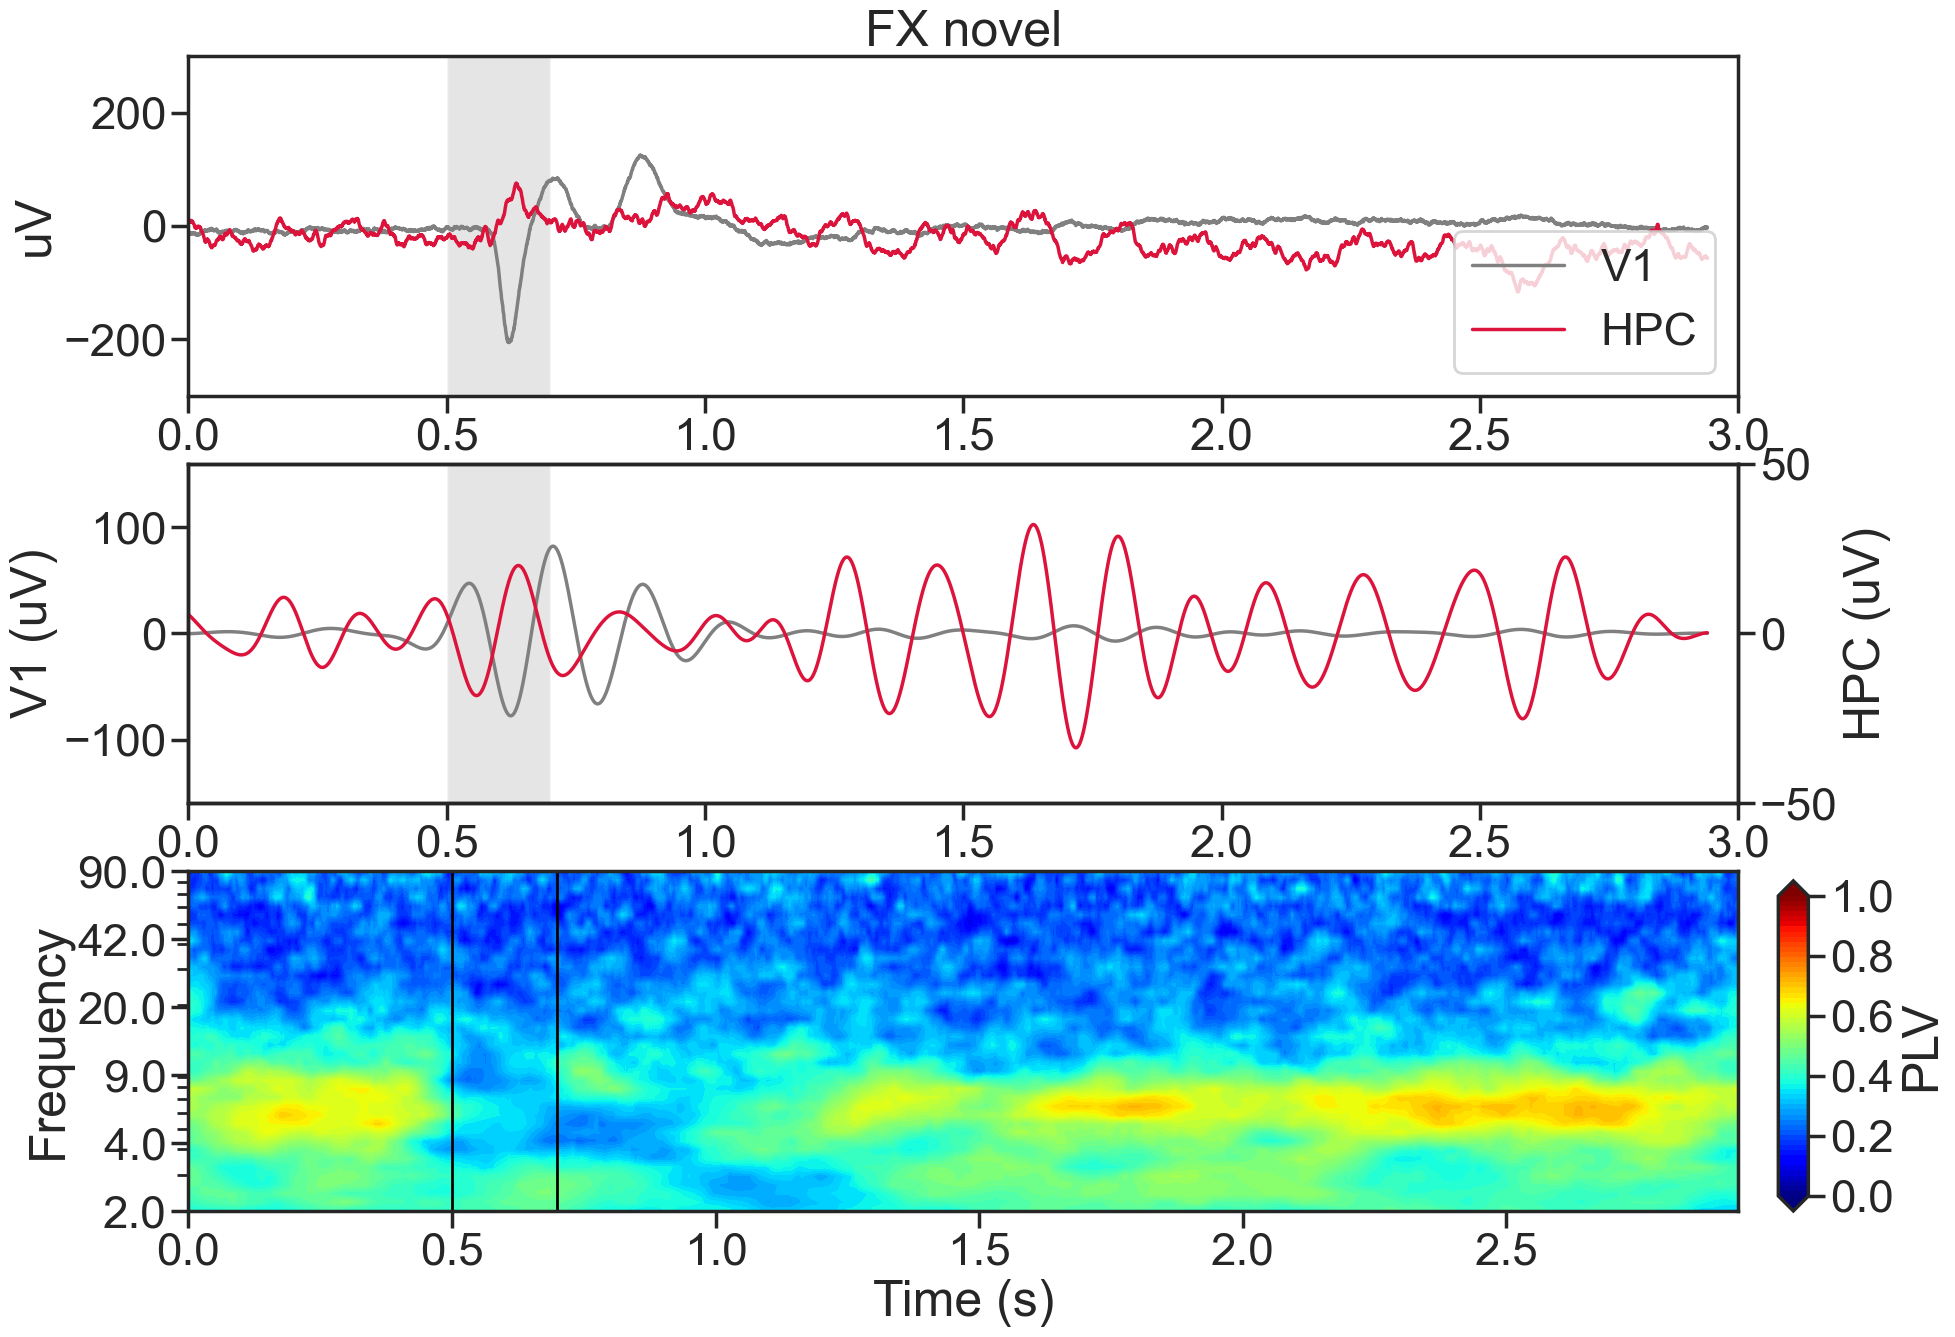

In [220]:
nrows, ncols = 3,1
f,ax=plt.subplots(nrows, ncols, figsize=(20*ncols,5*nrows))

#VEP line plots
mean_ch_traceV1 = my_all_mean[V1_mean_ch,:]
time_arr2_V1 = np.linspace(0, mean_ch_traceV1.shape[0]/sr, mean_ch_traceV1.shape[0])
mean_ch_traceHPC = my_all_mean[HPC_mean_ch,:]
time_arr2_HPC = np.linspace(0, mean_ch_traceHPC.shape[0]/sr, mean_ch_traceHPC.shape[0])
ax[0].plot(time_arr2_V1, mean_ch_traceV1, label='V1', color='grey')
ax[0].plot(time_arr2_HPC, mean_ch_traceHPC, label='HPC', color='crimson')
ax[0].legend(loc="lower right")
ax[0].set_title(f'FX {scenario}')
ax[0].set_xlabel('')
ax[0].set_xlim([0,3.0])
ax[0].set_ylim([-300,300])
ax[0].set_ylabel('uV')
ax[0].axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

# Theta filtered VEP line plots
filt_v1 = butter_bandpass_filter(mean_ch_traceV1)
filt_hpc = butter_bandpass_filter(mean_ch_traceHPC)
ax[1].plot(time_arr2_V1, filt_v1, label='V1', color='grey')
ax1 = ax[1].twinx()
ax1.plot(time_arr2_HPC, filt_hpc, label='HPC', color='crimson')
ax[1].set_xlabel('')
ax[1].set_xlim([0,3.0])
ax[1].set_ylim([-160,160])
ax1.set_ylim([-50,50])
ax[1].set_ylabel('V1 (uV)')
ax1.set_ylabel('HPC (uV)')
ax[1].axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

# PLV plot
all_tmp=np.mean(np.stack(fx_tmpdf.plv.values), axis=0)
tf_plot = ax[2].contourf(time, frex, all_tmp, cmap='jet', extend='both', levels=np.linspace(0.,1.0,60))
ax[2].set_yscale('log')
ax[2].set_xticks(np.arange(0,7500,1250))
ax[2].set_xticklabels(np.arange(0,3,0.5))
ax[2].set_yticks(np.logspace(np.log10(min_freq),np.log10(max_freq),6))
ax[2].set_yticklabels(np.round(np.logspace(np.log10(min_freq),np.log10(max_freq),6)))
# ax[2].set_title(f'V1/HPC PLV: FX {scenario}')
ax[2].axvspan(2500*0.5, 2500*0.7, ec ='black', lw=2, fill=False)
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Frequency')
cb_tf = f.add_axes([.92, 0.11, 0.015, 0.22])
cb_tf = f.colorbar(tf_plot,cax=cb_tf,ticks=np.arange(0,1.1,0.2),shrink=0.9)
cb_tf.set_label('PLV')

# sns.despine()

# Change the end of this next line with a new file name!!
if yes_save_plots:
    file_name = f"V1HPC_Vep_thetaVep_PLV_fx_{scenario}.pdf"
    out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
    plt.savefig(out_path, transparent=True)

plt.show()

# PLV heatmaps for each mouse in both WT and FX genotype

In [221]:
# for et in wtfx_plv_df.et.unique():
#     tmp = wtfx_plv_df[wtfx_plv_df['et'] == et]
#     tmp2=np.mean(np.stack(tmp.plv.values), axis=0)
    
#     f,ax=plt.subplots(1,1,figsize=(10,3))
#     tf_plot = ax.contourf(time, frex, tmp2, cmap='jet', extend='both', levels=np.linspace(0.,1.0,60))
    
#     ax.set_yscale('log')
#     ax.set_xticks(np.arange(0,7500,1250))
#     ax.set_xticklabels(np.arange(0,3,0.5))
#     ax.set_yticks(np.logspace(np.log10(min_freq),np.log10(max_freq),6))
#     ax.set_yticklabels(np.round(np.logspace(np.log10(min_freq),np.log10(max_freq),6)))
#     ax.set_title(et)
#     plt.axvspan(2500*0.5, 2500*0.7, ec='black', lw=3, fill=False)

#     ax.set_xlabel('Time (s)')
#     ax.set_ylabel('Frequency')

#     cb_tf = f.add_axes([.92, 0.1, 0.02, 0.8])
#     cb_tf = f.colorbar(tf_plot,cax=cb_tf,ticks=np.arange(0,1.1,0.2))
#     cb_tf.set_label('PLV')
    
#     sns.despine()
#     plt.show()

# Quantify PLV

In [222]:
def quantify_PLV(in_array, frex, time_window, group, idx):
    time_lower = int(time_window[0]*2500)
    time_upper = int(time_window[1]*2500)
    tmp0 = np.nanmean(in_array[(frex>=2) & (frex<4)], axis=0)[time_lower:time_upper]
    tmp1 = np.nanmean(in_array[(frex>=4) & (frex<8)], axis=0)[time_lower:time_upper]
    tmp2 = np.nanmean(in_array[(frex>=8) & (frex<12)], axis=0)[time_lower:time_upper]
    tmp3 = np.nanmean(in_array[(frex>=12) & (frex<30)], axis=0)[time_lower:time_upper]
    # tmp4 = np.nanmean(in_array[(frex>=30) & (frex<40)], axis=0)[time_lower:time_upper]
    # tmp5 = np.nanmean(in_array[(frex>=50) & (frex<70)], axis=0)[time_lower:time_upper]
    tmp6 = np.nanmean(in_array[(frex>=30) & (frex<70)], axis=0)[time_lower:time_upper]
    delta = tmp0.mean()
    theta = tmp1.mean()
    alpha = tmp2.mean()
    beta = tmp3.mean()
    # lowgamma = tmp4.mean()
    # highgamma = tmp5.mean()
    gamma= tmp6.mean()
    osc = ['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz']#, '30-40Hz', '50-70Hz']
    PLV = [delta, theta, alpha, beta, gamma]#, lowgamma, highgamma]
    tf_df = pd.DataFrame({'osc':osc, 'PLV':PLV})
    tf_df['mouse'] = idx
    tf_df['group'] = group
    return tf_df

def get_PLV_values(in_array, frex, group, time_window=[0.5,1.0]):
    tf_q_ls = []
    for idx in range(in_array.shape[0]):
        data = in_array[idx]
        foo_df = quantify_PLV(data, frex, time_window, group, idx) #function defined above!
        tf_q_ls.append(foo_df)
    new_df = pd.concat(tf_q_ls, ignore_index=True)
    return new_df

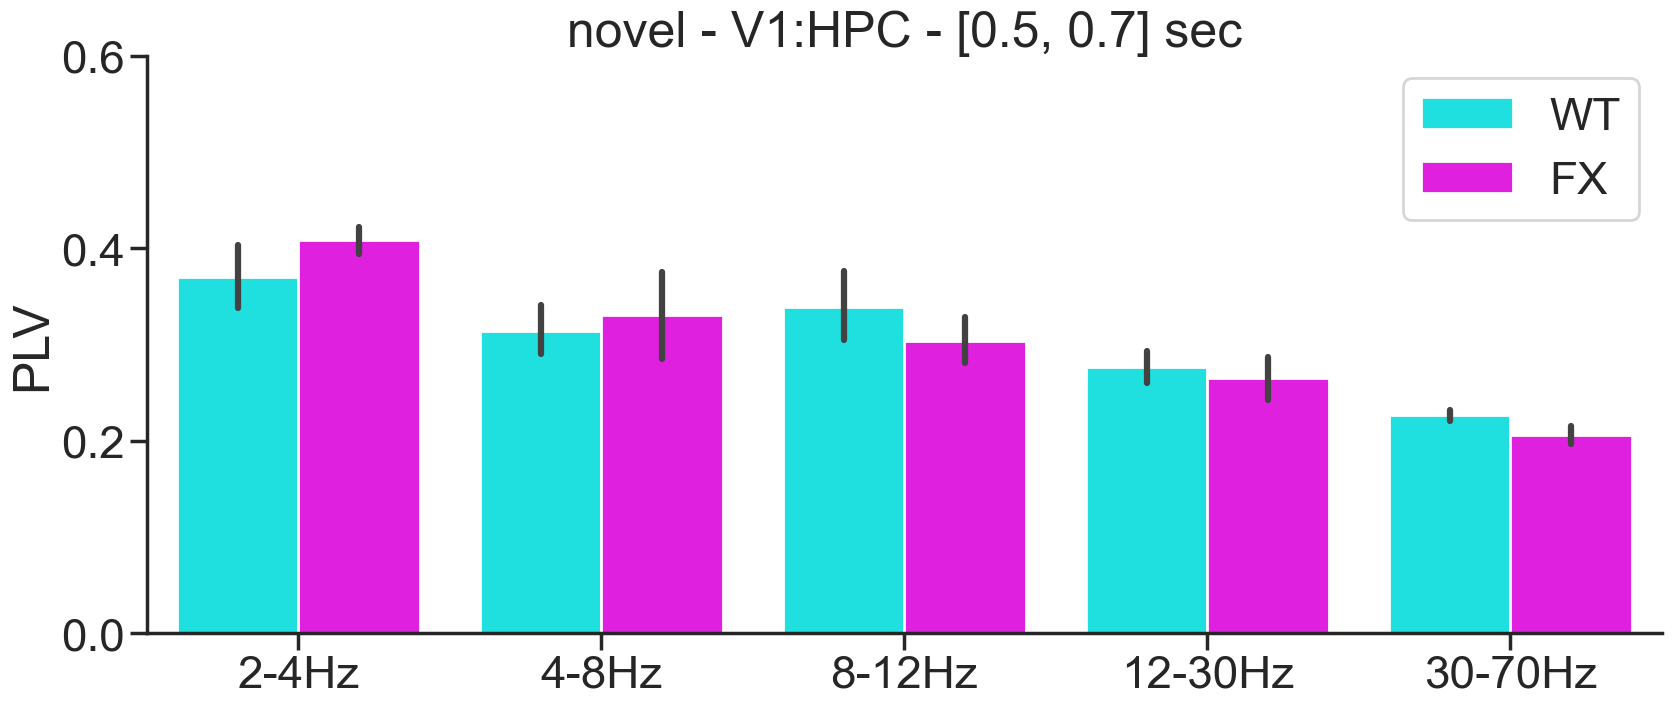

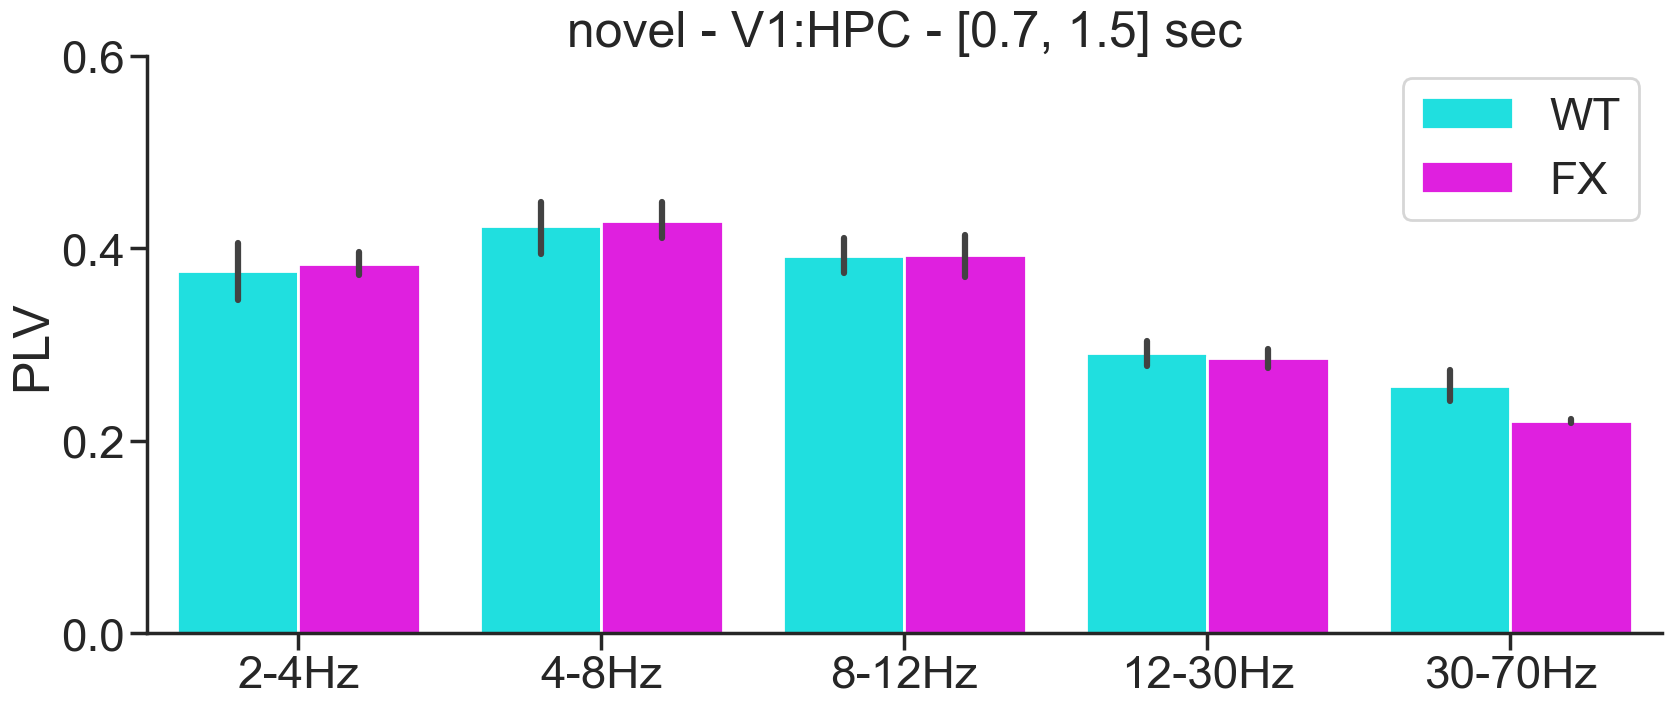

In [223]:
my_time = [[0.5,0.7], [0.7,1.5]]

timeWin_PLV = []
for time1 in my_time:
    wt_all_tmp = np.stack(wt_tmpdf.plv.values)
    fx_all_tmp = np.stack(fx_tmpdf.plv.values)
    wt_plv_quant = get_PLV_values(wt_all_tmp, frex, group='WT', time_window=time1)
    fx_plv_quant = get_PLV_values(fx_all_tmp, frex, group='FX', time_window=time1)
    plv_quant = pd.concat([wt_plv_quant, fx_plv_quant], ignore_index=True)
    plv_quant['timeWin'] = str(time1)
    timeWin_PLV.append(plv_quant)
    
    g = sns.catplot(x='osc', y='PLV', data=plv_quant, kind = 'bar', 
                    hue='group', hue_order=['WT','FX'], palette=sns.color_palette(['cyan', 'magenta']),
                    legend=False,
                    height = 8, aspect=2.2,
                    order=['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'],#,'30-40Hz', '50-70Hz'],
                    errorbar=('ci', 68))
    g.set_xticklabels(['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'], rotation=0)
    plt.title(f'{scenario} - V1:HPC - {time1} sec')
    plt.xlabel('')
    plt.yticks([0,0.2,0.4,0.6])
    plt.ylabel('PLV')
    plt.legend(loc="upper right")
    sns.despine()

    # Change the end of this next line with a new file name!!
    if yes_save_plots:
        file_name = f"PLV_quant_wtfx_{time1}_{scenario}.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
    plt.show()
timeWin_PLV_df = pd.concat(timeWin_PLV)

In [224]:
for time0 in my_time:
    stats_plv_df = timeWin_PLV_df[timeWin_PLV_df.timeWin == str(time0)]
    print(f'Scenario: {scenario}')
    print(f'PLV time window: {time0}\n')
    for hz_val, df in stats_plv_df.groupby('osc'):
        wt_vals = df[df['group']=='WT'].PLV.values
        fx_vals = df[df['group']=='FX'].PLV.values
        U, p = stats.mannwhitneyu(wt_vals, fx_vals)
        print(f'{hz_val} --- U: {U}; p val: {p}')
    print(f'N: {len(wt_vals)} (wt), {len(fx_vals)} (fx)')
    print('\nstats.mannwhitneyu')

Scenario: novel
PLV time window: [0.5, 0.7]

12-30Hz --- U: 37.0; p val: 0.480148909827134
2-4Hz --- U: 21.0; p val: 0.355843980076084
30-70Hz --- U: 44.0; p val: 0.14252880816093372
4-8Hz --- U: 32.0; p val: 0.8705675391295156
8-12Hz --- U: 31.0; p val: 0.956686155113512
N: 10 (wt), 6 (fx)

stats.mannwhitneyu
Scenario: novel
PLV time window: [0.7, 1.5]

12-30Hz --- U: 31.0; p val: 0.956686155113512
2-4Hz --- U: 27.0; p val: 0.7859582650872928
30-70Hz --- U: 44.0; p val: 0.14252880816093372
4-8Hz --- U: 27.0; p val: 0.7859582650872928
8-12Hz --- U: 30.0; p val: 1.0
N: 10 (wt), 6 (fx)

stats.mannwhitneyu


# PLV across situations

In [242]:
my_time = [[0.5,0.7], [0.7,1.5]]

timeWin_PLV = []
for time1 in my_time:
    for situ, sDF in big_plv.groupby('situ'):
        wt_all_tmp = np.stack(sDF[sDF.group=='wt'].plv.values)
        fx_all_tmp = np.stack(sDF[sDF.group=='fx'].plv.values)
        wt_plv_quant = get_PLV_values(wt_all_tmp, frex, group='WT', time_window=time1)
        fx_plv_quant = get_PLV_values(fx_all_tmp, frex, group='FX', time_window=time1)
        plv_quant = pd.concat([wt_plv_quant, fx_plv_quant], ignore_index=True)
        plv_quant['timeWin'] = str(time1)
        plv_quant['situ'] = situ
        timeWin_PLV.append(plv_quant)
timeWin_PLV_df = pd.concat(timeWin_PLV)

wt_timeWin_plv = timeWin_PLV_df[timeWin_PLV_df.group=='WT']
fx_timeWin_plv = timeWin_PLV_df[timeWin_PLV_df.group=='FX']

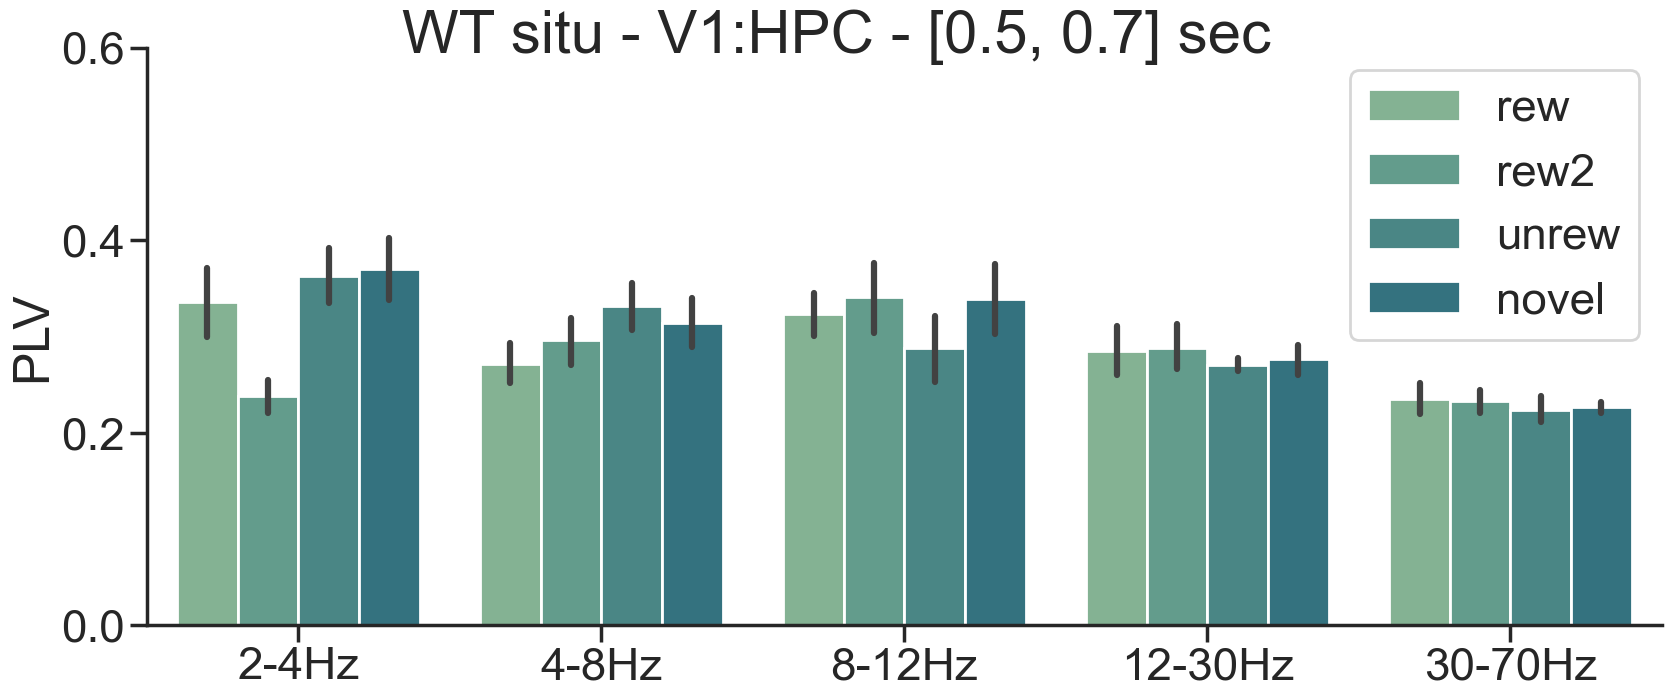

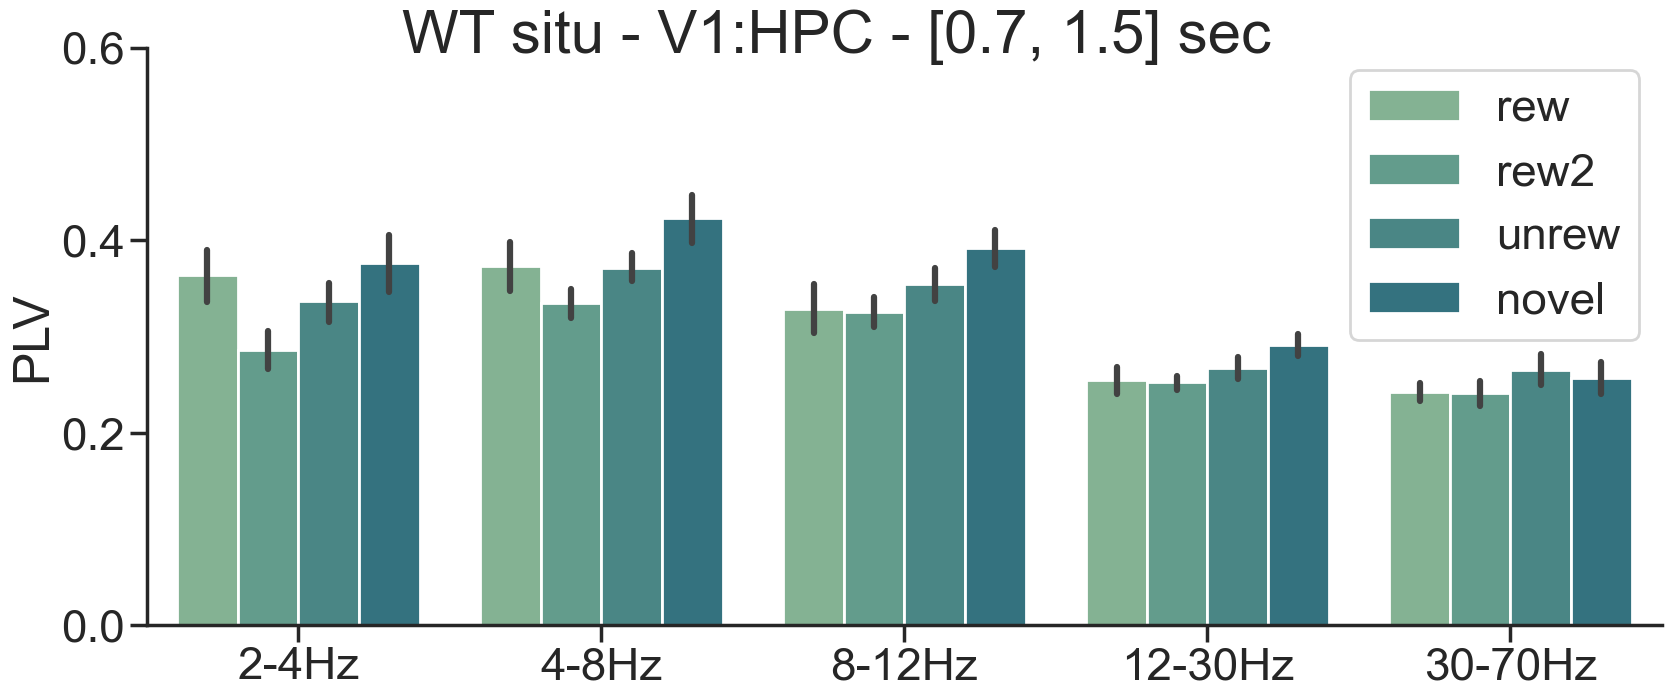

In [258]:
for idx,time1 in enumerate(my_time):
    g = sns.catplot(x='osc', y='PLV', data=wt_timeWin_plv[wt_timeWin_plv.timeWin==str(time1)], kind = 'bar', 
                    hue='situ', hue_order=['rew','rew2','unrew','novel'], palette=sns.color_palette('crest'),
                    legend=False,
                    height = 8, aspect=2.2,
                    order=['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'],#,'30-40Hz', '50-70Hz'],
                    errorbar=('ci', 68))
    g.set_xticklabels(['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'], rotation=0)
    plt.suptitle(f'WT situ - V1:HPC - {time1} sec')
    plt.xlabel('')
    plt.yticks([0,0.2,0.4,0.6])
    plt.ylabel('PLV')
    plt.legend(loc="upper right")
    sns.despine()
    
    # Change the end of this next line with a new file name!!
    if yes_save_plots:
        file_name = f"PLV_quant_wt_{time1}_allSitu.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
        
    plt.show()

In [256]:
for time0 in my_time:
    stats_plv_df = wt_timeWin_plv[wt_timeWin_plv.timeWin == str(time0)]
    print(f'Group: WT')
    print(f'PLV time window: {time0}\n')
    for hz_val, df in stats_plv_df.groupby('osc'):
        rew_vals = df[df['situ']=='rew'].PLV.values
        rew2_vals = df[df['situ']=='rew2'].PLV.values
        unrew_vals = df[df['situ']=='unrew'].PLV.values
        novel_vals = df[df['situ']=='novel'].PLV.values
        U, p = stats.mannwhitneyu(rew_vals, rew2_vals)
        print(f'{hz_val} rew~rew2 --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew_vals, unrew_vals)
        print(f'{hz_val} rew~unrew --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew_vals, novel_vals)
        print(f'{hz_val} rew~novel --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew2_vals, unrew_vals)
        print(f'{hz_val} rew2~unrew --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew2_vals, novel_vals)
        print(f'{hz_val} rew2~novel --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(unrew_vals, novel_vals)
        print(f'{hz_val} unrew~novel --- U: {U}; p val: {p}')
    print(f'N: {len(rew_vals)} (rew), {len(rew2_vals)} (rew2), {len(unrew_vals)} (unrew), {len(novel_vals)} (novel)\n')
print('stats.mannwhitneyu')

Group: WT
PLV time window: [0.5, 0.7]

12-30Hz rew~rew2 --- U: 51.0; p val: 0.9698045577720108
12-30Hz rew~unrew --- U: 46.0; p val: 0.7910295772981756
12-30Hz rew~novel --- U: 47.0; p val: 0.8498835087000991
12-30Hz rew2~unrew --- U: 53.0; p val: 0.8498835087000991
12-30Hz rew2~novel --- U: 51.0; p val: 0.9698045577720108
12-30Hz unrew~novel --- U: 53.0; p val: 0.8498835087000991
2-4Hz rew~rew2 --- U: 78.0; p val: 0.037348161341940696
2-4Hz rew~unrew --- U: 50.0; p val: 1.0
2-4Hz rew~novel --- U: 42.0; p val: 0.5701699724963722
2-4Hz rew2~unrew --- U: 10.0; p val: 0.0027859446415680706
2-4Hz rew2~novel --- U: 16.0; p val: 0.01120695479765041
2-4Hz unrew~novel --- U: 45.0; p val: 0.7333439595749962
30-70Hz rew~rew2 --- U: 41.0; p val: 0.5198945163559368
30-70Hz rew~unrew --- U: 60.0; p val: 0.47200855766610705
30-70Hz rew~novel --- U: 39.0; p val: 0.42665907124897295
30-70Hz rew2~unrew --- U: 61.0; p val: 0.42665907124897295
30-70Hz rew2~novel --- U: 57.0; p val: 0.622652636570054
30-7

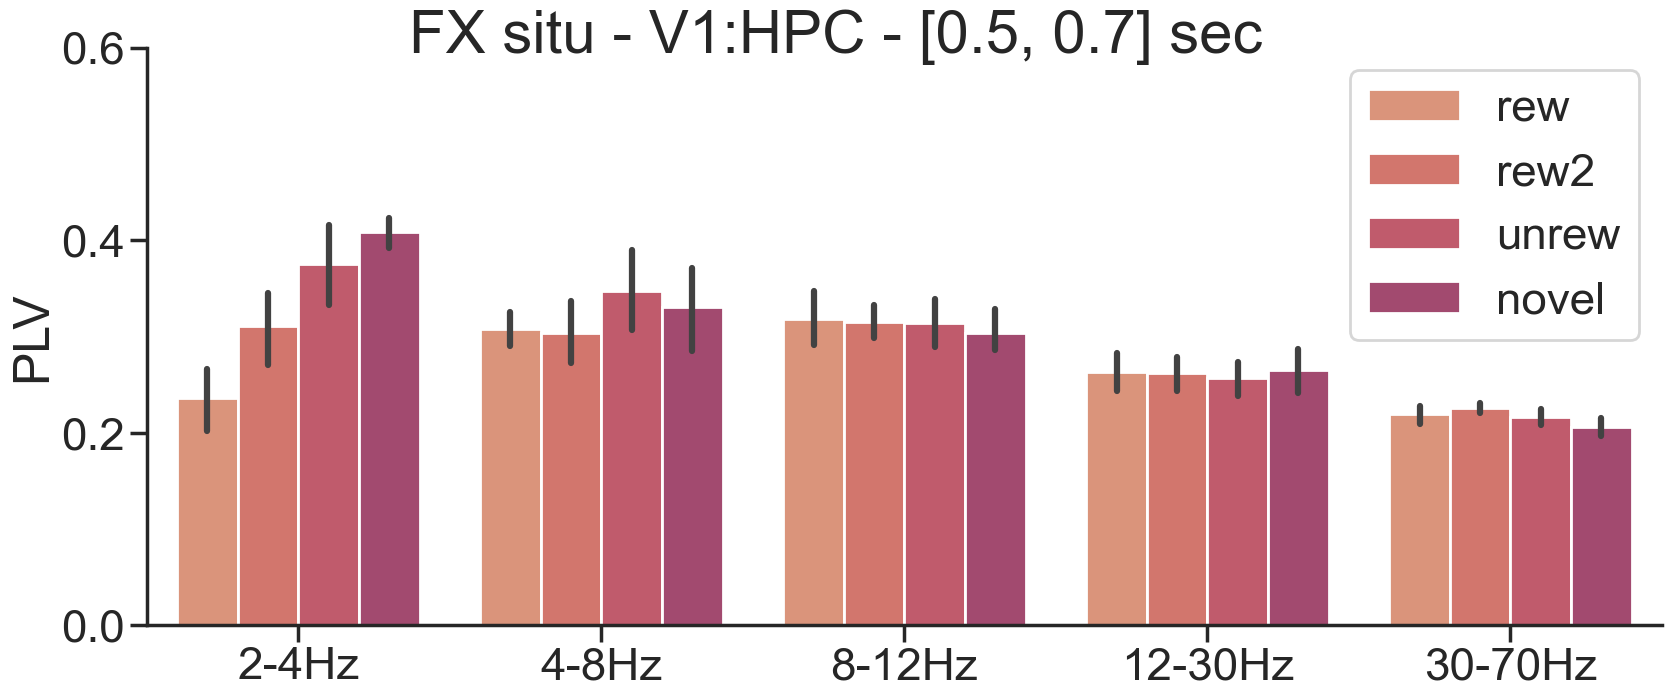

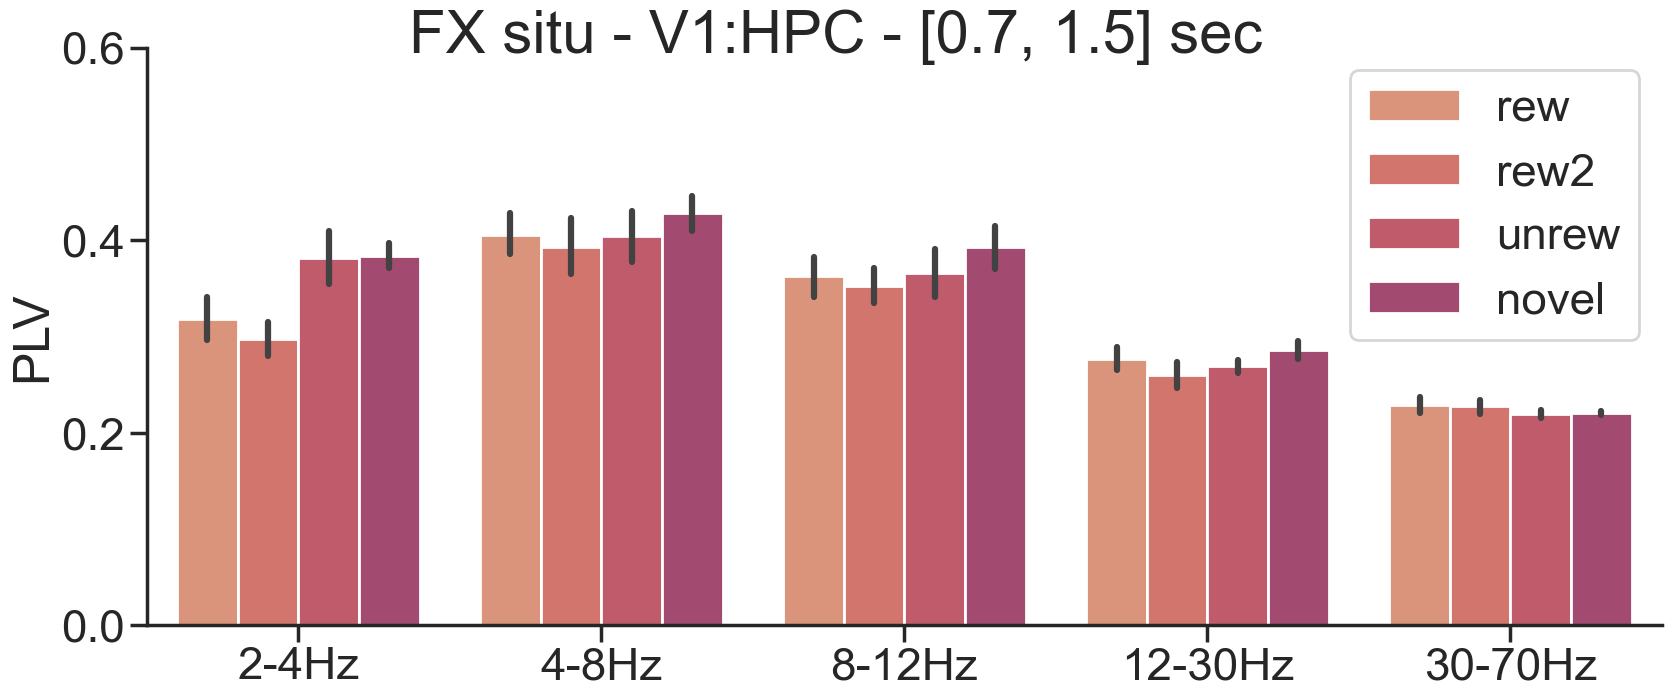

In [260]:
for idx,time1 in enumerate(my_time):
    g = sns.catplot(x='osc', y='PLV', data=fx_timeWin_plv[fx_timeWin_plv.timeWin==str(time1)], kind = 'bar', 
                    hue='situ', hue_order=['rew','rew2','unrew','novel'], palette=sns.color_palette('flare'),
                    legend=False,
                    height = 8, aspect=2.2,
                    order=['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'],#,'30-40Hz', '50-70Hz'],
                    errorbar=('ci', 68))
    g.set_xticklabels(['2-4Hz', '4-8Hz', '8-12Hz', '12-30Hz', '30-70Hz'], rotation=0)
    plt.suptitle(f'FX situ - V1:HPC - {time1} sec')
    plt.xlabel('')
    plt.yticks([0,0.2,0.4,0.6])
    plt.ylabel('PLV')
    plt.legend(loc="upper right")
    sns.despine()
    
    # Change the end of this next line with a new file name!!
    if yes_save_plots:
        file_name = f"PLV_quant_fx_{time1}_allSitu.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
        
    plt.show()

In [261]:
for time0 in my_time:
    stats_plv_df = fx_timeWin_plv[fx_timeWin_plv.timeWin == str(time0)]
    print(f'Group: FX')
    print(f'PLV time window: {time0}\n')
    for hz_val, df in stats_plv_df.groupby('osc'):
        rew_vals = df[df['situ']=='rew'].PLV.values
        rew2_vals = df[df['situ']=='rew2'].PLV.values
        unrew_vals = df[df['situ']=='unrew'].PLV.values
        novel_vals = df[df['situ']=='novel'].PLV.values
        U, p = stats.mannwhitneyu(rew_vals, rew2_vals)
        print(f'{hz_val} rew~rew2 --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew_vals, unrew_vals)
        print(f'{hz_val} rew~unrew --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew_vals, novel_vals)
        print(f'{hz_val} rew~novel --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew2_vals, unrew_vals)
        print(f'{hz_val} rew2~unrew --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(rew2_vals, novel_vals)
        print(f'{hz_val} rew2~novel --- U: {U}; p val: {p}')
        U, p = stats.mannwhitneyu(unrew_vals, novel_vals)
        print(f'{hz_val} unrew~novel --- U: {U}; p val: {p}')
    print(f'N: {len(rew_vals)} (rew), {len(rew2_vals)} (rew2), {len(unrew_vals)} (unrew), {len(novel_vals)} (novel)\n')
print('stats.mannwhitneyu')

Group: FX
PLV time window: [0.5, 0.7]

12-30Hz rew~rew2 --- U: 34.0; p val: 0.8784770784770783
12-30Hz rew~unrew --- U: 33.0; p val: 0.959129759129759
12-30Hz rew~novel --- U: 24.0; p val: 1.0
12-30Hz rew2~unrew --- U: 34.0; p val: 0.8784770784770783
12-30Hz rew2~novel --- U: 28.0; p val: 0.662004662004662
12-30Hz unrew~novel --- U: 27.0; p val: 0.7545787545787546
2-4Hz rew~rew2 --- U: 18.0; p val: 0.1605283605283605
2-4Hz rew~unrew --- U: 11.0; p val: 0.028127428127428127
2-4Hz rew~novel --- U: 4.0; p val: 0.007992007992007992
2-4Hz rew2~unrew --- U: 23.0; p val: 0.3822843822843822
2-4Hz rew2~novel --- U: 12.0; p val: 0.14185814185814188
2-4Hz unrew~novel --- U: 18.0; p val: 0.4908424908424909
30-70Hz rew~rew2 --- U: 22.0; p val: 0.32820512820512815
30-70Hz rew~unrew --- U: 37.0; p val: 0.6453768453768453
30-70Hz rew~novel --- U: 30.0; p val: 0.4908424908424909
30-70Hz rew2~unrew --- U: 43.0; p val: 0.2786324786324786
30-70Hz rew2~novel --- U: 36.0; p val: 0.14185814185814188
30-70Hz 

# Phase Difference

In [225]:
phd_wtfx_df=wtfx_plv_df
phd_wtfx_df['freq'] = 0
phd_wtfx_df['freq']= phd_wtfx_df['freq'].apply(lambda x: np.logspace(np.log10(min_freq),np.log10(max_freq),num_frex))
phd_wtfx_df=phd_wtfx_df.explode(['phsdiff','freq']).reset_index()

#specify the frequency range and time window you want to quantify phase difference from
my_freq = [3.9,8.1]

my_time = [[0.5,0.7], [0.7,1.5]]

n_bins = 30
r_max = 2.4

C:\Users\AChub_Lab\AppData\Local\Temp\ipykernel_18728\1165786246.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phd_wtfx_df['freq'] = 0
C:\Users\AChub_Lab\AppData\Local\Temp\ipykernel_18728\1165786246.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phd_wtfx_df['freq']= phd_wtfx_df['freq'].apply(lambda x: np.logspace(np.log10(min_freq),np.log10(max_freq),num_frex))


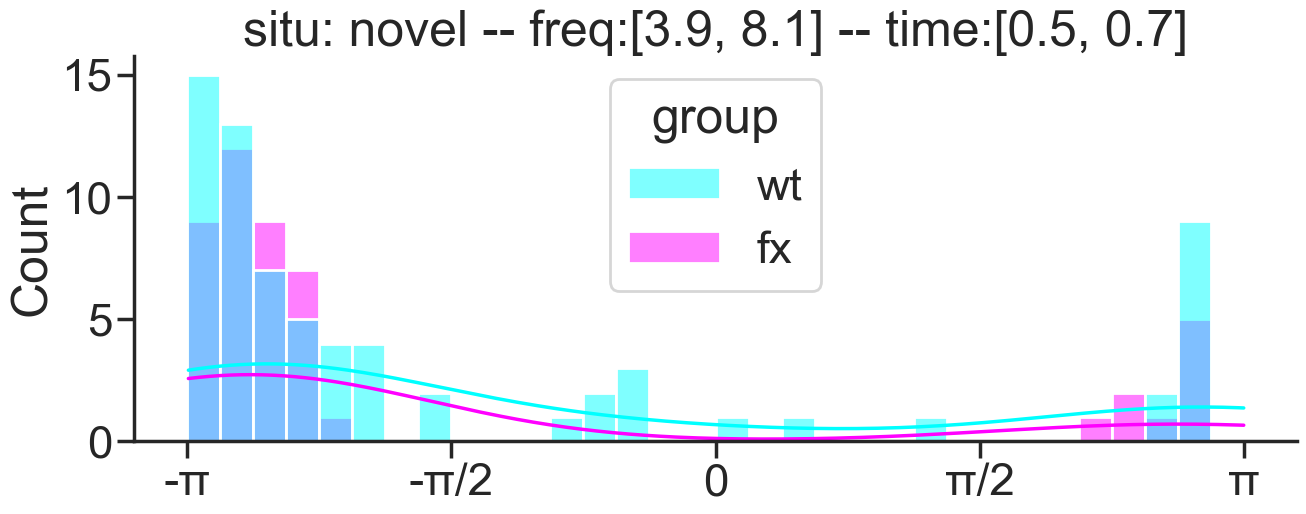

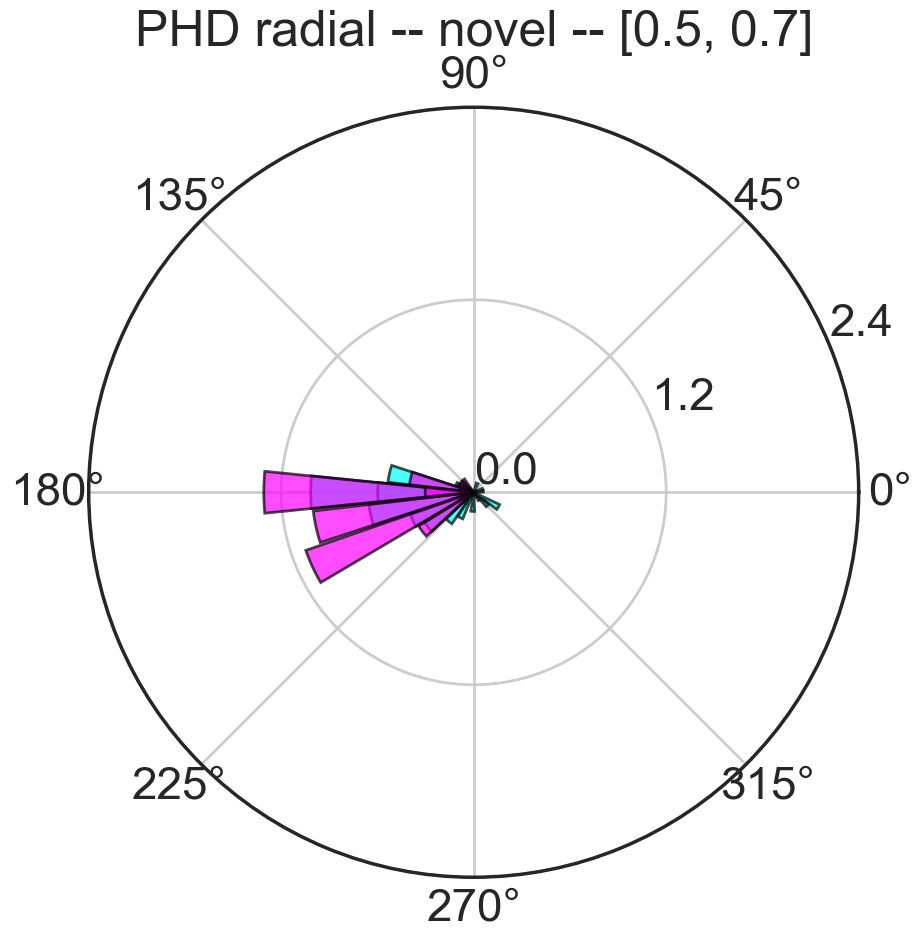

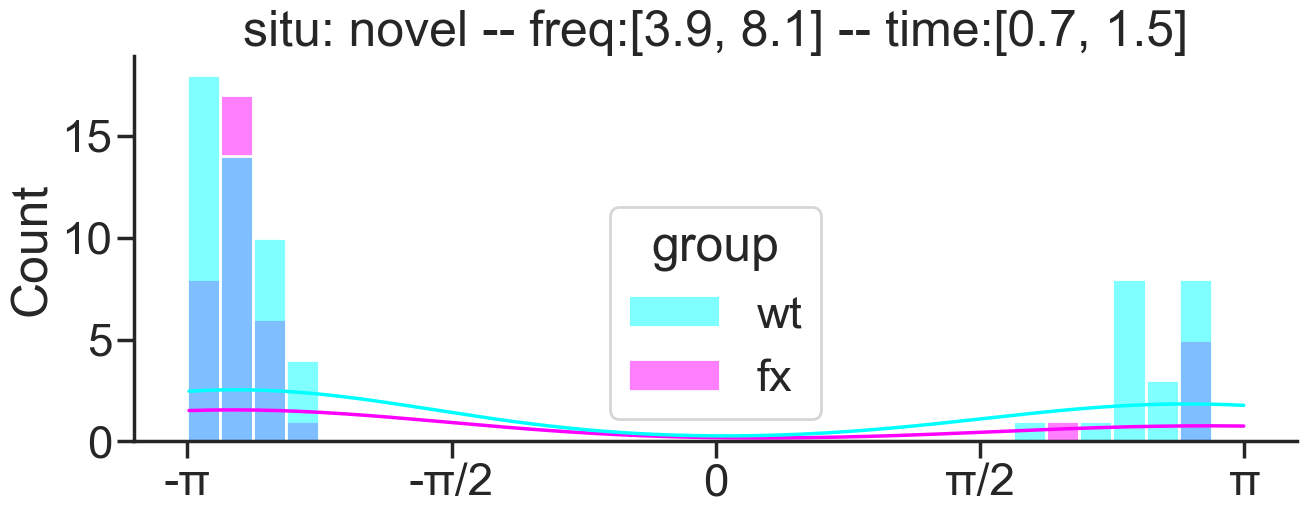

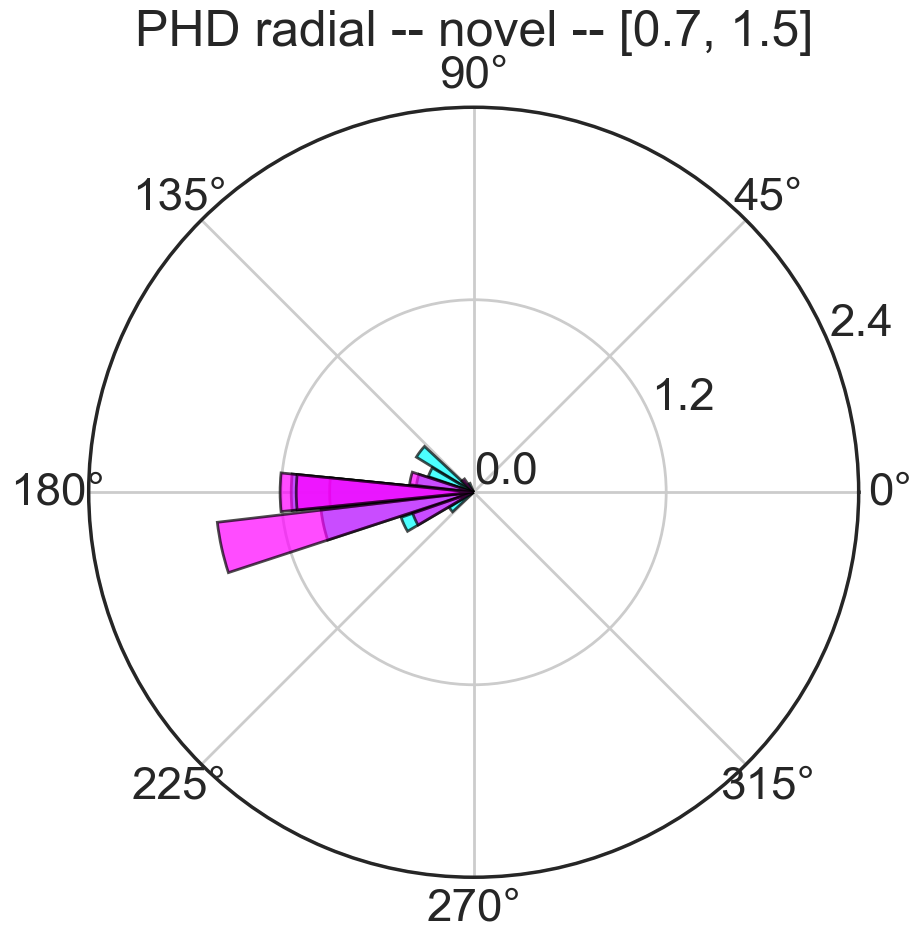

In [226]:
for time0 in my_time:
    phdif=phd_wtfx_df[(phd_wtfx_df.freq>my_freq[0]) & (phd_wtfx_df.freq<my_freq[1])]

    phdif.loc[:, 'phsdiff']=phdif.phsdiff.apply(lambda x:pg.circ_mean(x[int(time0[0]*Sampling_Rate):int(time0[1]*Sampling_Rate)]))

    #hist plot
    f,ax=plt.subplots(1,1,figsize=(15,5),sharey=True)
    sns.histplot(phdif,x=list(phdif.phsdiff.values),
                bins=np.arange(-np.pi,np.pi,np.pi/16),
                ax=ax,kde=True,stat='count',hue='group', hue_order=['wt','fx'],
                 common_norm=True,palette=sns.color_palette(['cyan', 'magenta']))
    ax.set_xticks(np.arange(-np.pi,np.pi+1,np.pi/2).round(2))
    ax.set_xticklabels(["-\u03c0", "-\u03c0/2", "0", "\u03c0/2", "\u03c0"])
    plt.title(f'situ: {scenario} -- freq:{my_freq} -- time:{time0}')
    sns.despine()
    # Change the end of this next line with a new file name!!
    if yes_save_plots:
        file_name = f"PHD_hist_wtfx_{time0}_{scenario}.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
    plt.show()

    #radial plots
    fig = plt.figure(figsize=(20,10))
    hist_wt, bin_edges = np.histogram(phdif[phdif.group=='wt'].phsdiff.values, bins=n_bins, density=True)
    hist_fx, bin_edges = np.histogram(phdif[phdif.group=='fx'].phsdiff.values, bins=n_bins, density=True)
    theta = np.linspace(-1*np.pi, np.pi, n_bins)
    ax = plt.subplot(111, projection='polar')
    ax.bar(theta, hist_wt, bottom=0.0, color='cyan', edgecolor='black', width=0.2, alpha=0.7)
    ax.bar(theta, hist_fx, bottom=0.0, color='magenta', edgecolor='black', width=0.2, alpha=0.7)
    ax.set_title(f'PHD radial -- {scenario} -- {time0}')
    ax.set_rmax(r_max)
    ax.set_rticks(np.linspace(0, r_max, 3))
    # Change the end of this next line with a new file name!!
    if yes_save_plots:
        file_name = f"PHD_radial_wtfx_{time0}_{scenario}.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
    plt.show()

# PHD across time
instead of limited to a single time window average

In [227]:
my_freq = [3.9,8.1]
my_timeStep = 0.1

hz48_phdif=phd_wtfx_df[(phd_wtfx_df.freq>my_freq[0]) & (phd_wtfx_df.freq<my_freq[1])]

In [228]:
mouse_df = []
for et,etDF in hz48_phdif.groupby('et'):
    ttt_ls, phd_ls = [], []
    for ttt in np.round(np.linspace(0*Sampling_Rate,2.7*Sampling_Rate, 300)):
        ttt_ls.append(ttt/2500)
        int_time = [int(ttt), int(ttt+(my_timeStep*Sampling_Rate))]
        phd_ls.append(etDF.phsdiff.apply(lambda x:pg.circ_mean(x[int_time[0]:int_time[1]])).mean())
    phd_alltime = pd.DataFrame({'start_time':ttt_ls,
                                'phd_val':phd_ls,
                               'et':et,
                               'group':etDF.group.unique()[0]})
    mouse_df.append(phd_alltime)
PHD_across_time = pd.concat(mouse_df, ignore_index=True)
# PHD_across_time['situ'] = scenario
PHD_across_time.head()

,start_time,phd_val,et,group
0,0.0000,-1.321410,0_fx,fx
1,0.0092,-1.308591,0_fx,fx
2,0.0180,-2.080101,0_fx,fx
3,0.0272,-2.066305,0_fx,fx
4,0.0360,-2.054526,0_fx,fx


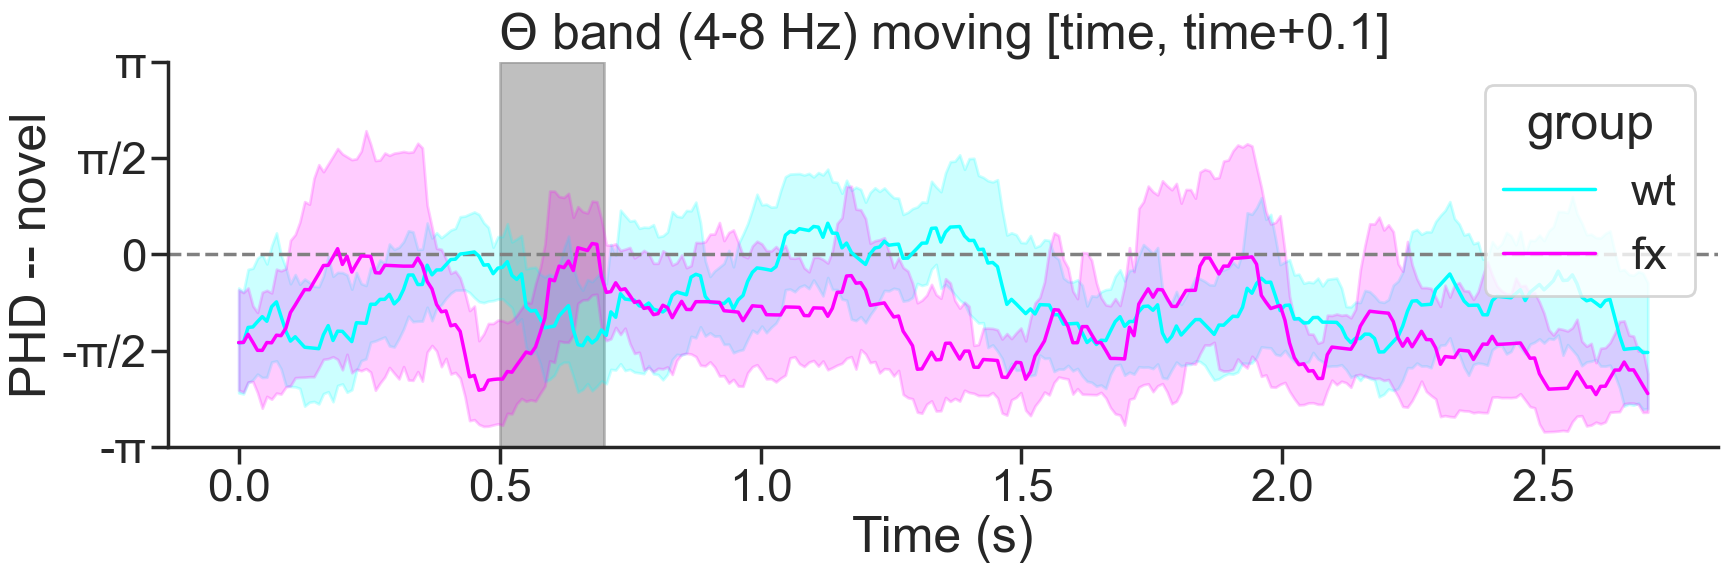

In [229]:
f,ax=plt.subplots(1,1,figsize=(20,5),sharey=True)
ax.axhline(0, linestyle='--', color='grey')
ax.axvspan(0.5,0.7, color='grey', alpha=0.5)

sns.lineplot(data=PHD_across_time, x='start_time', y='phd_val', ax=ax, #errorbar=None,
            hue='group', hue_order=['wt','fx'], palette=sns.color_palette(['cyan', 'magenta']))
ax.set_yticks(np.arange(-np.pi,np.pi+1,np.pi/2).round(2))
ax.set_yticklabels(["-\u03c0", "-\u03c0/2", "0", "\u03c0/2", "\u03c0"])
ax.set_title(r'${\Theta}$ band (4-8 Hz) moving [time, time+0.1]')
ax.set_ylabel(f"PHD -- {scenario}")
ax.set_xlabel('Time (s)')
sns.despine()

# Change the end of this next line with a new file name!!
if yes_save_plots:
    file_name = f"PHD_allTime_wtfx_{scenario}.pdf"
    out_path = r"C:\Users\AChub_Lab\Desktop\wtfx_behavior_plv"+"\\"+file_name
    plt.savefig(out_path, transparent=True)
plt.show()